In [51]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
from scipy.stats import bernoulli, dirichlet, multinomial, uniform, poisson,norm
import numpy as np
from scipy.linalg import toeplitz
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.stats import multivariate_normal, halfnorm
import itertools
import random
import h5py
from scipy.io import loadmat
import random
print('done')

done


In [52]:
data_path = r"C:\Users\katie\OneDrive\Desktop\Kaufman2014data\data"
os.listdir(data_path)

['Mjs.mat',
 'Mns.mat',
 'N,2009-09-18,1-2,good-ss.mat',
 'N,2010-08-12,1-2-3,decent-ss.mat',
 'RJ_20090918.mat',
 'RN_20100812.mat']

In [53]:
m_j = os.listdir(data_path)[0]
data_m = loadmat(data_path + '\\' + m_j)
exp1 = data_m.get('Mjs')
condit1 = exp1['cond']

inner1 = condit1[0]
print(inner1.dtype)
print(inner1.shape)
[inner1[i].shape for i in range(10)]
tryin = np.rec.array(inner1[1][0])
print(tryin.dtype.names)
print(tryin['mazeID'][5][0])
print(tryin['interpPSTH'][0])


object
(32,)
('mazeID', 'trialVersion', 'protoTrial', 'TargLocked', 'GoLocked', 'MoveLocked', 'interpPSTH')
[17]
[[ 95063.73459169]
 [ 95137.83874663]
 [ 95225.39576242]
 [ 95323.38859861]
 [ 95430.28335229]
 [ 95521.59617915]
 [ 95544.74943396]
 [ 95458.17015394]
 [ 95275.51601617]
 [ 95058.03744113]
 [ 94863.10656468]
 [ 94712.21231762]
 [ 94607.32612512]
 [ 94558.42350217]
 [ 94579.42312454]
 [ 94661.39221765]
 [ 94760.61462917]
 [ 94812.2887916 ]
 [ 94757.28720318]
 [ 94566.08791336]
 [ 94251.44746477]
 [ 93859.51565428]
 [ 93445.47745839]
 [ 93055.47887825]
 [ 92726.46944334]
 [ 92489.1947674 ]
 [ 92360.63238718]
 [ 92333.47463498]
 [ 92375.03497063]
 [ 92433.30649335]
 [ 92445.62453313]
 [ 92358.05536663]
 [ 92153.72650111]
 [ 91868.01978079]
 [ 91572.12726475]
 [ 91338.85841978]
 [ 91218.31038145]
 [ 91232.56997534]
 [ 91375.91027298]
 [ 91608.21095974]
 [ 91853.44454759]
 [ 92023.88427518]
 [ 92066.20961356]
 [ 91991.1513166 ]
 [ 91856.4377484 ]
 [ 91719.66467766]
 [ 91608.2392

In [54]:
# pass along a dataset to this function after loading it in with loadmat
class dataset: 
    """ A class representing one of the two datasets: N,2009-09-18,1-2,good-ss.mat or N,2010-08-12,1-2-3,decent-ss.mat.

    Attributes:
        Ns: all data retrieved from the Ns section of the matlab file
        data: the record array used to index through different types of data which were within self.Ns
        neuron: a list which counts from 1 to the total number of neurons, which are the neuron labels
        neu_type: a list of size neuron which has a 1 for a PMd neuron and a 2 for an M1 neuron 
    """
    
    
    def __init__(self, orig_data):
        """
        Initializes a dataset object.

        Parameters:
            orig_data: one of two datasets (N,2009-09-18,1-2,good-ss.mat or N,2010-08-12,1-2-3,decent-ss.mat) which has been loaded 
                in with the function loadmat 

        Attributes:
            Ns: all data retrieved from the Ns section of the matlab file
            data: the record array used to index through different types of data which were within self.Ns
            neuron: a list which counts from 1 to the total number of neurons, which are the neuron labels
            neu_type: a list of size neuron which has a 1 for a PMd neuron and a 2 for an M1 neuron        
        """
        self.Ns = orig_data.get('Ns')
        self.data = np.rec.array(self.Ns)
        self.neuron = self.data['cell']
        self.neu_type = self.data['oneForPMdtwoforM1']

        # flattening this into an array with the length equal to the number of neurons, instead of the number of neurons nested arrays  
        self.neu_type = np.array([int(x[0, 0]) for x in self.neu_type.flatten()])
        
       
       

    
    def PSTH (self):
        """
        Accesses the interpPSTH data from the original dataset and puts it into a 3D matrix
        
        returns:
            interpPSTH: a 3D matrix with dimensions [conditions, neurons, time bins] which contains the PSTH data points
        """

        interpPSTH = np.array([[self.data['cond'][0, neu][0, conds]['interpPSTH'] for neu in range(self.data['cond'].shape[1])]
        for conds in range(self.data['cond'][0,0].shape[1])
        ])
        interpPSTH = np.squeeze(interpPSTH)
        return interpPSTH

    
    def interpCues (self):
        """
        Creates an array for each of the qualities within the data: times, targetOn, goCue, moveStarts

        returns: 
            times_list: an array of the start of each time bin for every neuron dimensions are [neurons, time bins]
            targetOn_list: an array which contains the time when the target was presented (one time per neuron)
            goCue_list: an array which contains the time when the go cue was presented (one time per neuron)
            moveStarts_list: an array which contains the time when the movement started (one time per neuron)
        """
        # initializing lists 
        times_list = []
        targetOn_list=[]
        goCue_list=[]
        moveStarts_list=[]

        # filling the lists
        for nn_ in range(0,self.neuron.shape[1]):
            interpTimes = np.rec.array(self.data['interpTimes'][0,nn_])
            targetOn_list.append(interpTimes['targetOn'][0,0][0,0])
            goCue_list.append(interpTimes['goCue'][0,0][0,0])
            moveStarts_list.append(interpTimes['moveStarts'][0,0][0,0])
            times_list.append(interpTimes['times'][0,0][0,:])
        
        times_list = np.array(times_list)
        targetOn_list= np.array(targetOn_list)
        goCue_list = np.array(goCue_list)
        moveStarts_list = np.array(moveStarts_list)

        return times_list, targetOn_list, goCue_list, moveStarts_list

    
    def sort (self): 
        """
        Sorts the PSTH readouts and all outputs from interpCues by neuron location--either PMd or M1

        returns: 
            PMd_PSTH: the PSTH from all neural data which was recorded from a neuron in PMd--dimensions [condition, PMd neurons, time bins]
            PMd_times: an array of the start of each time bin for every neuron dimensions are [PMd neurons, time bins] in milliseconds
            PMd_targetOn: an array which contains the time when the target was presented for each PMd neuron recording (one time per neuron)
            PMd_goCue: an array which contains the time when the go cue was presented for each PMd neuron recording (one time per neuron)
            PMd_moveStarts: an array which contains the time when the movement started for each PMD neuron recording (one time per neuron)
            
            M1_PSTH: the PSTH from all neural data which was recorded from a neuron in PMd--dimensions [condition, PMd neurons, time bins]
            M1_times: an array of the start of each time bin for every neuron dimensions are [PMd neurons, time bins] in milliseconds
            M1_targetOn: an array which contains the time when the target was presented for each PMd neuron recording (one time per neuron)
            M1_goCue: an array which contains the time when the go cue was presented for each PMd neuron recording (one time per neuron)
            M1_moveStarts: an array which contains the time when the movement started for each PMD neuron recording (one time per neuron)

        """
        
        # finding the indexes for the PMd vs M1 neurons
        PMd_idx = np.where(self.neu_type == 1)[0]
        M1_idx = np.where(self.neu_type == 2)[0]

        print(PMd_idx)
        print(M1_idx)
        # Calling PSTH to access the interpPSTH neural data
        interpPSTH = self.PSTH()
        
        # Use those indices to index the neuron_data
        PMd_PSTH = interpPSTH[:, PMd_idx, :]
        M1_PSTH = interpPSTH[:, M1_idx, :]

        # Calling the times, targetOn, goCue, and moveStarts lists
        times, targetOn, goCue, moveStarts = self.interpCues()

        # Separating these lists by neuron areas PMd and M1
        PMd_times = times[PMd_idx,:]
        PMd_targetOn = targetOn[PMd_idx]
        PMd_goCue = goCue[PMd_idx]
        PMd_moveStarts = moveStarts[PMd_idx]

        M1_times = times[M1_idx,:]
        M1_targetOn = targetOn[M1_idx]
        M1_goCue = goCue[M1_idx]
        M1_moveStarts = moveStarts[M1_idx]
        

        return PMd_PSTH, PMd_times, PMd_targetOn, PMd_goCue, PMd_moveStarts, M1_PSTH, M1_times, M1_targetOn, M1_goCue, M1_moveStarts

                 
        

In [55]:
# sanity checks
neu_j = os.listdir(data_path)[2]
data = loadmat(data_path + '\\' + neu_j)
J_neural = dataset(data)
J_PSTH = J_neural.PSTH()
times, targetOn, goCue, moveStarts = J_neural.interpCues()
print(times[0])
print(targetOn)
print(goCue)
print(moveStarts)
# print(times.shape)
# print(targetOn.shape)
# print(goCue.shape)
# print(moveStarts.shape)
PMd, PMd_times, PMd_target, PMd_goCue, PMd_move, M1, M1_times, M1_target, M1_goCue, M1_move= J_neural.sort()
# print (PMd.shape)
# print(PMd_times.shape)
# print(PMd_target.shape)
# print(PMd_goCue.shape)
# print(PMd_move.shape)
# print(M1.shape)
# print(M1_times.shape)
# print(M1_target.shape)
# print(M1_goCue.shape)
# print(M1_move.shape)


[   0   10   20   30   40   50   60   70   80   90  100  110  120  130
  140  150  160  170  180  190  200  210  220  230  240  250  260  270
  280  290  300  310  320  330  340  350  360  370  380  390  400  410
  420  430  440  450  460  470  480  490  500  510  520  530  540  550
  560  570  580  590  600  610  620  630  640  650  660  670  680  690
  700  710  720  730  740  750  760  770  780  790  800  810  820  830
  840  850  860  870  880  890  900  910  920  930  940  950  960  970
  980  990 1000 1010 1020 1030 1040 1050 1060 1070 1080 1090 1100 1110
 1120 1130 1140 1150 1160 1170 1180 1190 1200 1210 1220 1230 1240 1250
 1260 1270 1280 1290 1300 1310 1320 1330 1340 1350 1360 1370 1380 1390
 1400 1410 1420 1430 1440 1450 1460 1470 1480 1490 1500 1510 1520 1530
 1540 1550 1560 1570 1580 1590 1600 1610 1620 1630 1640 1650 1660 1670
 1680 1690 1700 1710 1720 1730 1740 1750 1760 1770 1780 1790 1800 1810
 1820 1830 1840 1850 1860 1870 1880 1890 1900 1910 1920 1930 1940 1950
 1960 

In [56]:
J_all = { 'interpPSTH': J_PSTH, 'times': times, 'targetOn': targetOn, 'goCue': goCue, 'moveStarts': moveStarts}
J_PMd = {'interpPSTH': PMd, 'times': PMd_times, 'targetOn': PMd_target, 'goCue': PMd_goCue, 'moveStarts': PMd_move}
J_M1 =  {'interpPSTH': M1, 'times': M1_times, 'targetOn': M1_target, 'goCue': M1_goCue, 'moveStarts': M1_move} 

In [57]:
def neu_plot (neu1, time1, neu2, time2, label1, label2):
    plt.plot(time1, neu1, color = 'blue', label = label1)
    plt.plot(time2, neu2, color = 'orange', label = label2)
    plt.axvline(x=targetOn[1], color='r', linestyle='--', label = 'target on')
    plt.axvline(x=goCue[1], color='g', linestyle='--', label = 'go cue')
    plt.axvline(x=moveStarts[1], color='y', linestyle='--', label = 'movement start')
    plt.title('PSTH of PMd and M1 Neurons')
    plt.ylabel('spikes per second')
    plt.xlabel('time (ms)')
    plt.legend()

In [58]:
J_neu = {'J_all': J_all, 'J_PMd': J_PMd, 'J_M1': J_M1}



In [59]:
import pickle
base_path =r"C:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_neu.pkl', 'wb') as f:
    pickle.dump(J_neu, f)
del f


<>:3: SyntaxWarning: invalid escape sequence '\J'
<>:3: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_41820\4093136812.py:3: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_neu.pkl', 'wb') as f:


In [60]:
import pickle
base_path =r"C:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_all.pkl', 'wb') as f:
    pickle.dump(J_all, f)
del f
with open(base_path+'\J_PMd.pkl', 'wb') as f:
    pickle.dump(J_PMd, f)
del f
with open(base_path+'\J_M1.pkl', 'wb') as f:
    pickle.dump(J_M1, f)
del f

<>:3: SyntaxWarning: invalid escape sequence '\J'
<>:6: SyntaxWarning: invalid escape sequence '\J'
<>:9: SyntaxWarning: invalid escape sequence '\J'
<>:3: SyntaxWarning: invalid escape sequence '\J'
<>:6: SyntaxWarning: invalid escape sequence '\J'
<>:9: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_41820\3528967074.py:3: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_all.pkl', 'wb') as f:
C:\Users\katie\AppData\Local\Temp\ipykernel_41820\3528967074.py:6: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_PMd.pkl', 'wb') as f:
C:\Users\katie\AppData\Local\Temp\ipykernel_41820\3528967074.py:9: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_M1.pkl', 'wb') as f:


In [61]:
# # checking that the code works with the second dataset
# data_name2 = os.listdir(data_path)[3]
# data2 = loadmat(data_path + data_name2)
# test2 = dataset(data2)
# PSTH_data2 = test2.PSTH()
# times2, targetOn2, goCue2, moveStarts2 = test2.interpCues()
# print(PSTH_data2.shape)
# print(times2.shape)
# print(targetOn2.shape)
# print(goCue2.shape)
# print(moveStarts2)
# PMd_2, M1_2 = test2.sort()
# print (PMd_2.shape)
# print(M1_2.shape)
# print(targetOn2[1])
# # Check if all arrays are equal to the first one
# all_equal = all(np.array_equal(arr, times2[0]) for arr in times2)

# print(all_equal)  # True

In [62]:
# plt.plot(times[1,:], M1[1,1,:], color = 'blue', label = 'M1 neuron 2')
# plt.plot(times[1,:], M1[1,40,:], color = 'orange', label = 'M1 neuron 41')
# plt.axvline(x=targetOn[1], color='r', linestyle='--', label = 'target on')
# plt.axvline(x=goCue[1], color='g', linestyle='--', label = 'go cue')
# plt.axvline(x=moveStarts[1], color='y', linestyle='--', label = 'movement start')
# plt.title('PSTH of M1 Neurons')
# plt.ylabel('spikes per second')
# plt.xlabel('time (ms)')
# plt.legend()

In [63]:
# pass along a dataset to this function after loading it in with loadmat
class dataset_FR: 
    """ A class representing one of the two datasets: N,2009-09-18,1-2,good-ss.mat or N,2010-08-12,1-2-3,decent-ss.mat.

    Attributes:
        Ns: all data retrieved from the Ns section of the matlab file
        data: the record array used to index through different types of data which were within self.Ns
        neuron: a list which counts from 1 to the total number of neurons, which are the neuron labels
        neu_type: a list of size neuron which has a 1 for a PMd neuron and a 2 for an M1 neuron 
    """
    
    
    def __init__(self, orig_data):
        """
        Initializes a dataset object.

        Parameters:
            orig_data: one of two datasets (N,2009-09-18,1-2,good-ss.mat or N,2010-08-12,1-2-3,decent-ss.mat) which has been loaded 
                in with the function loadmat 

        Attributes:
            Ns: all data retrieved from the Ns section of the matlab file
            data: the record array used to index through different types of data which were within self.Ns
            neuron: a list which counts from 1 to the total number of neurons, which are the neuron labels
            neu_type: a list of size neuron which has a 1 for a PMd neuron and a 2 for an M1 neuron        
        """
        self.Ns = orig_data.get('Ns')
        self.data = np.rec.array(self.Ns)
        self.neuron = self.data['cell']
        self.neu_type = self.data['oneForPMdtwoforM1']

        # flattening this into an array with the length equal to the number of neurons, instead of the number of neurons nested arrays  
        self.neu_type = np.array([int(x[0, 0]) for x in self.neu_type.flatten()])
       
    
    def FR (self, J):
        """
        Accesses the interpPSTH data from the original dataset and puts it into a 3D matrix
        
        returns:
            interpPSTH: a 3D matrix with dimensions [conditions, neurons, time bins] which contains the PSTH data points
        """

        targLocked_FRs = np.array([[self.data['cond'][0, neu][0, conds]['TargLocked']['meanFR'][0,0][0] for neu in range(self.data['cond'].shape[1])]
        for conds in range(self.data['cond'][0,0].shape[1])
        ])
        targLocked_FRs = np.squeeze(targLocked_FRs)

        goLocked_FRs = np.array([[self.data['cond'][0, neu][0, conds]['GoLocked']['meanFR'][0,0][0] for neu in range(self.data['cond'].shape[1])]
        for conds in range(self.data['cond'][0,0].shape[1])
        ])
        goLocked_FRs = np.squeeze(goLocked_FRs)

        moveLocked_FRs = np.array([[self.data['cond'][0, neu][0, conds]['MoveLocked']['meanFR'][0,0][0] for neu in range(self.data['cond'].shape[1])]
        for conds in range(self.data['cond'][0,0].shape[1])
        ])
        moveLocked_FRs = np.squeeze(moveLocked_FRs)

        if J: 
            dt = 10
            T = 236
            N_full = np.full((108, 202, T), np.nan)
            N_full[:, :, 0:86] = targLocked_FRs
            N_full[:, :, 90:136] = goLocked_FRs
            N_full[:, :, 115:236] = moveLocked_FRs

        else: 
            T = 228
            N_full = np.full((27, 275, T), np.nan)
            N_full[:, :, 0:86] = targLocked_FRs
            N_full[:, :, 88:134] = goLocked_FRs
            N_full[:, :, 107:228] = moveLocked_FRs

        return N_full

    
    def interpCues (self):
        """
        Creates an array for each of the qualities within the data: times, targetOn, goCue, moveStarts

        returns: 
            times_list: an array of the start of each time bin for every neuron dimensions are [neurons, time bins]
            targetOn_list: an array which contains the time when the target was presented (one time per neuron)
            goCue_list: an array which contains the time when the go cue was presented (one time per neuron)
            moveStarts_list: an array which contains the time when the movement started (one time per neuron)
        """
        # initializing lists 
        times_list = []
        targetOn_list=[]
        goCue_list=[]
        moveStarts_list=[]

        # filling the lists
        
        interpTimes = np.rec.array(self.data['interpTimes'][0,0])
        targetOn_list.append(interpTimes['targetOn'][0,0][0,0])
        goCue_list.append(interpTimes['goCue'][0,0][0,0])
        moveStarts_list.append(interpTimes['moveStarts'][0,0][0,0])
        times_list.append(interpTimes['times'][0,0][0,:])
        
        times_list = np.array(times_list)
        targetOn_list= np.array(targetOn_list)
        goCue_list = np.array(goCue_list)
        moveStarts_list = np.array(moveStarts_list)

        return times_list, targetOn_list, goCue_list, moveStarts_list

    
    def sort (self, J): 
        """
        Sorts the PSTH readouts and all outputs from interpCues by neuron location--either PMd or M1

        returns: 
            PMd_PSTH: the PSTH from all neural data which was recorded from a neuron in PMd--dimensions [condition, PMd neurons, time bins]
            PMd_times: an array of the start of each time bin for every neuron dimensions are [PMd neurons, time bins] in milliseconds
            PMd_targetOn: an array which contains the time when the target was presented for each PMd neuron recording (one time per neuron)
            PMd_goCue: an array which contains the time when the go cue was presented for each PMd neuron recording (one time per neuron)
            PMd_moveStarts: an array which contains the time when the movement started for each PMD neuron recording (one time per neuron)
            
            M1_PSTH: the PSTH from all neural data which was recorded from a neuron in PMd--dimensions [condition, PMd neurons, time bins]
            M1_times: an array of the start of each time bin for every neuron dimensions are [PMd neurons, time bins] in milliseconds
            M1_targetOn: an array which contains the time when the target was presented for each PMd neuron recording (one time per neuron)
            M1_goCue: an array which contains the time when the go cue was presented for each PMd neuron recording (one time per neuron)
            M1_moveStarts: an array which contains the time when the movement started for each PMD neuron recording (one time per neuron)

        """
        
        # finding the indexes for the PMd vs M1 neurons
        PMd_idx = np.where(self.neu_type == 1)[0]
        M1_idx = np.where(self.neu_type == 2)[0]

        # Calling PSTH to access the interpPSTH neural data
        mean_FR = self.FR(J)
        
        # Use those indices to index the neuron_data
        PMd_mean_FR = mean_FR[:, PMd_idx, :]
        M1_mean_FR= mean_FR[:, M1_idx, :]

        return PMd_mean_FR, M1_mean_FR

                 
        

In [87]:
# sanity checks
neu_j = os.listdir(data_path)[2]
data = loadmat(data_path + '\\' + neu_j)
J = True
J_neur = dataset_FR(data)
J_FR= J_neur.FR(J)
print(J_FR.shape)
times, targetOn, goCue, moveStarts = J_neur.interpCues()
print(times)
print(targetOn)
print(goCue)
print(moveStarts)
PMd_FR, M1_FR = J_neur.sort(J)
print (PMd_FR.shape)
print(M1_FR.shape)

J_all_FR = { 'mean_FR': J_FR, 'times': times, 'targetOn': targetOn, 'goCue': goCue, 'moveStarts': moveStarts}
J_PMd_FR = {'mean_FR': PMd_FR}
J_M1_FR =  {'mean_FR': M1_FR} 
J_neu_FR = {'J_all_FR': J_all_FR, 'J_PMd_FR': J_PMd_FR, 'J_M1_FR': J_M1_FR}

import pickle
base_path =r"C:\Users\katie\OneDrive\Desktop\Thesis"
with open(os.path.join(base_path, "J_neu_FR.pkl"), 'wb') as f:
    pickle.dump(J_neu_FR, f)
del f


(108, 202, 236)
[[   0   10   20   30   40   50   60   70   80   90  100  110  120  130
   140  150  160  170  180  190  200  210  220  230  240  250  260  270
   280  290  300  310  320  330  340  350  360  370  380  390  400  410
   420  430  440  450  460  470  480  490  500  510  520  530  540  550
   560  570  580  590  600  610  620  630  640  650  660  670  680  690
   700  710  720  730  740  750  760  770  780  790  800  810  820  830
   840  850  860  870  880  890  900  910  920  930  940  950  960  970
   980  990 1000 1010 1020 1030 1040 1050 1060 1070 1080 1090 1100 1110
  1120 1130 1140 1150 1160 1170 1180 1190 1200 1210 1220 1230 1240 1250
  1260 1270 1280 1290 1300 1310 1320 1330 1340 1350 1360 1370 1380 1390
  1400 1410 1420 1430 1440 1450 1460 1470 1480 1490 1500 1510 1520 1530
  1540 1550 1560 1570 1580 1590 1600 1610 1620 1630 1640 1650 1660 1670
  1680 1690 1700 1710 1720 1730 1740 1750 1760 1770 1780 1790 1800 1810
  1820 1830 1840 1850 1860 1870 1880 1890 1900 1

In [ ]:
# import pickle
# base_path =r"C:\Users\katie\OneDrive\Desktop\Thesis"
# with open(os.path.join(base_path, "J_all_FR.pkl"), 'wb') as f:
#     pickle.dump(J_all_FR, f)

# with open(os.path.join(base_path, "J_PMd_FR.pkl"), 'wb') as f:
#     pickle.dump(J_PMd_FR, f)

# with open(os.path.join(base_path, "J_M1_FR.pkl"), 'wb') as f:
#     pickle.dump(J_M1_FR, f)

In [88]:
N_N = os.listdir(data_path)[3]
data_nn = loadmat(data_path + '\\' + N_N)
J = False
N_neur = dataset_FR(data_nn)
N_FR = N_neur.FR(J)
print(N_FR.shape)
times, targetOn, goCue, moveStarts = N_neur.interpCues()
print(times)
print(targetOn)
print(goCue)
print(moveStarts)
PMd_FR, M1_FR = N_neur.sort(J)
print (PMd_FR.shape)
print(M1_FR.shape)

N_all_FR = { 'mean_FR': N_FR, 'times': times, 'targetOn': targetOn, 'goCue': goCue, 'moveStarts': moveStarts}
N_PMd_FR = {'mean_FR': PMd_FR}
N_M1_FR =  {'mean_FR': M1_FR} 
N_neu_FR = {'N_all_FR': N_all_FR, 'N_PMd_FR': N_PMd_FR, 'N_M1_FR': N_M1_FR}

import pickle
base_path =r"C:\Users\katie\OneDrive\Desktop\Thesis"
with open(os.path.join(base_path, "N_neu_FR.pkl"), 'wb') as f:
    pickle.dump(N_neu_FR, f)
del f


(27, 275, 228)
[[   0   10   20   30   40   50   60   70   80   90  100  110  120  130
   140  150  160  170  180  190  200  210  220  230  240  250  260  270
   280  290  300  310  320  330  340  350  360  370  380  390  400  410
   420  430  440  450  460  470  480  490  500  510  520  530  540  550
   560  570  580  590  600  610  620  630  640  650  660  670  680  690
   700  710  720  730  740  750  760  770  780  790  800  810  820  830
   840  850  860  870  880  890  900  910  920  930  940  950  960  970
   980  990 1000 1010 1020 1030 1040 1050 1060 1070 1080 1090 1100 1110
  1120 1130 1140 1150 1160 1170 1180 1190 1200 1210 1220 1230 1240 1250
  1260 1270 1280 1290 1300 1310 1320 1330 1340 1350 1360 1370 1380 1390
  1400 1410 1420 1430 1440 1450 1460 1470 1480 1490 1500 1510 1520 1530
  1540 1550 1560 1570 1580 1590 1600 1610 1620 1630 1640 1650 1660 1670
  1680 1690 1700 1710 1720 1730 1740 1750 1760 1770 1780 1790 1800 1810
  1820 1830 1840 1850 1860 1870 1880 1890 1900 19

In [ ]:
# import pickle
# base_path =r"C:\Users\katie\OneDrive\Desktop\Thesis"
# with open(os.path.join(base_path, "N_all_FR.pkl"), 'wb') as f:
#     pickle.dump(N_all_FR, f)

# with open(os.path.join(base_path, "N_PMd_FR.pkl"), 'wb') as f:
#     pickle.dump(N_PMd_FR, f)

# with open(os.path.join(base_path, "N_M1_FR.pkl"), 'wb') as f:
#     pickle.dump(N_M1_FR, f)

In [68]:
# pass along a dataset to this function after loading it in with loadmat for muscle data
# must include a 1 for dataset Mjs and any other number for dataset Mns
class muscle_dataset: 
    """ 
    A class representing one of the two datasets: Mjs.mat or Mns.mat.

    Attributes:
        all_data:is all data retrieved from the Mjs or Mns section of the matlab file
        data: the record array used to index through different types of data which were within self.all_data
        
    """
    
    def __init__(self, orig_data, j_or_n):
        """
        Initializes a dataset object.

        Parameters:
            orig_data: one of two datasets (Mjs.mat or Mns.mat) which has been loaded in with the function loadmat 
            j_or_n: specifies if dataset Mjs or Mns has been passed through--put a 1 for Mjs.mat or any other number for Mns.mat

        Attributes:
            all_data:is all data retrieved from the Mjs or Mns section of the matlab file
            muscles: the number of muscles which were recorded from within this dataset
            data: the record array used to index through different types of data which were within self.all_data       
        """
        if j_or_n == 1: 
            self.all_data = orig_data.get('Mjs')
            self.muscles = 32
        else: 
            self.all_data = orig_data.get('Mns')
            self.muscles = 12
        self.data = np.rec.array(self.all_data)
        

    def PSTH (self):
        """
        Accesses the interpPSTH data from the dataset and puts it into a 3D matrix
        
        returns:
            interpPSTH: a 3D matrix with dimensions [conditions, muscle fibers, time bins] which contains the PSTH data points
        """
        
        interpPSTH = np.array([[self.data['cond'][0, i][0, j]['interpPSTH'] for i in range(self.data['cond'].shape[1])]
        for j in range(self.data['cond'][0,0].shape[1])
        ])
        interpPSTH = np.squeeze(interpPSTH)
        return interpPSTH

    
    def interpCues (self):
        """
        Creates an array for each of the qualities within the data: times, targetOn, goCue, moveStarts

        returns: 
            times_list: an array of the start of each time bin for every neuron dimensions are [neurons, time bins]
            targetOn_list: an array which contains the time when the target was presented (one time per neuron)
            goCue_list: an array which contains the time when the go cue was presented (one time per neuron)
            moveStarts_list: an array which contains the time when the movement started (one time per neuron)
        """
        times_list = []
        targetOn_list=[]
        goCue_list=[]
        moveStarts_list=[]
        for nm_ in range(0,self.muscles):
            interpTimes = np.rec.array(self.data['interpTimes'][0,nm_])
            targetOn_list.append(interpTimes['targetOn'][0,0][0,0])
            goCue_list.append(interpTimes['goCue'][0,0][0,0])
            moveStarts_list.append(interpTimes['moveStarts'][0,0][0,0])
            times_list.append(interpTimes['times'][0,0][0,:])
         
        times_list = np.array(times_list)
        targetOn_list= np.array(targetOn_list)
        goCue_list = np.array(goCue_list)
        moveStarts_list = np.array(moveStarts_list)

        return times_list, targetOn_list, goCue_list, moveStarts_list


    def muscle_names (self):
        """
        finds and returns the names of the files, which contains the muscle name

        returns: 
            names: a 1D array which contains the name of the muscle fiber that was recorded from 
        """
        names = np.array([entry.item() for entry in self.data['fileName'].flatten()])
        return names
                 
        

In [69]:
muscle_path = os.listdir(data_path)[0]
data_m = loadmat(data_path + '\\' + muscle_path)
muscle_j = muscle_dataset(data_m, 1)
muscle_PSTH = muscle_j.PSTH()
time_m, targetOn_m, goCue_m, moveStarts_m = muscle_j.interpCues()
muscle_name = muscle_j.muscle_names()

print(moveStarts_m)
muscle_set_J =  {'interpPSTH': muscle_PSTH, 'times': time_m, 'targetOn': targetOn_m, 'goCue': goCue_m, 'moveStarts': moveStarts_m, 'names': muscle_name} 


[1550 1550 1550 1550 1550 1550 1550 1550 1550 1550 1550 1550 1550 1550
 1550 1550 1550 1550 1550 1550 1550 1550 1550 1550 1550 1550 1550 1550
 1550 1550 1550 1550]


In [70]:
muscle_set_J =  {'interpPSTH': muscle_PSTH, 'times': time_m, 'targetOn': targetOn_m, 'goCue': goCue_m, 'moveStarts': moveStarts_m, 'names': muscle_name} 


In [71]:
import pickle
base_path =r"C:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', 'wb') as f:
    pickle.dump(muscle_set_J, f)
del f

<>:3: SyntaxWarning: invalid escape sequence '\J'
<>:3: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_41820\3957788210.py:3: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', 'wb') as f:


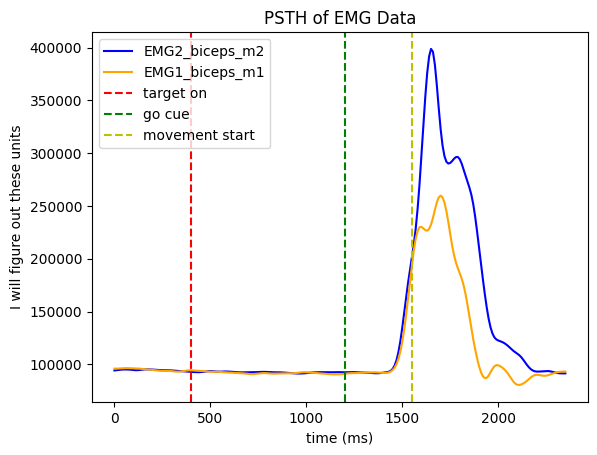

In [72]:
plt.plot(time_m[1,:], muscle_PSTH[1,0,:], color = 'blue', label = muscle_name[1])
plt.plot(time_m[0,:], muscle_PSTH[0,0,:], color = 'orange', label = muscle_name[0] )
plt.axvline(x=targetOn_m[1], color='r', linestyle='--', label = 'target on')
plt.axvline(x=goCue_m[1], color='g', linestyle='--', label = 'go cue')
plt.axvline(x=moveStarts_m[1], color='y', linestyle='--', label = 'movement start')
plt.title('PSTH of EMG Data')
plt.ylabel('I will figure out these units')
plt.xlabel('time (ms)')
plt.legend()

In [73]:
muscle_path2 = os.listdir(data_path)[1]
data_m2 = loadmat(data_path + '\\' +  muscle_path2)
muscle_n = muscle_dataset(data_m2, 0)
muscle_PSTH_n = muscle_n.PSTH()
time_n, targetOn_n, goCue_n, moveStarts_n = muscle_n.interpCues()
muscle_name_n = muscle_n.muscle_names()
print(muscle_PSTH_n.shape)
print(muscle_name_n.shape)
# Check if all arrays are equal to the first one
all_equal = all(np.array_equal(arr, time_n[0]) for arr in time_n)

print(all_equal)  # True

(27, 12, 228)
(12,)
True


In [74]:
def neu_plot (neu1, time1, neu2, time2, label1, label2):
    plt.plot(time1, neu1, color = 'blue', label = label1)
    plt.plot(time2, neu2, color = 'orange', label = label2)
    plt.axvline(x=targetOn[1], color='r', linestyle='--', label = 'target on')
    plt.axvline(x=goCue[1], color='g', linestyle='--', label = 'go cue')
    plt.axvline(x=moveStarts[1], color='y', linestyle='--', label = 'movement start')
    plt.title('PSTH of PMd and M1 Neurons')
    plt.ylabel('spikes per second')
    plt.xlabel('time (ms)')
    plt.legend()

In [75]:
N_N = os.listdir(data_path)[3]
data_nn = loadmat(data_path + '\\' + N_N)
N_neural = dataset(data_nn)
N_PSTH = N_neural.PSTH()
times, targetOn, goCue, moveStarts = N_neural.interpCues()
print(targetOn)
print(N_PSTH.shape)
# print(times.shape)
# print(targetOn.shape)
# print(goCue.shape)
# print(moveStarts.shape)
PMd, PMd_times, PMd_target, PMd_goCue, PMd_move, M1, M1_times, M1_target, M1_goCue, M1_move= N_neural.sort()
print(moveStarts)

[400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 40

In [76]:
N_all = { 'interpPSTH': N_PSTH, 'times': times, 'targetOn': targetOn, 'goCue': goCue, 'moveStarts': moveStarts}
N_PMd = {'interpPSTH': PMd, 'times': PMd_times, 'targetOn': PMd_target, 'goCue': PMd_goCue, 'moveStarts': PMd_move}
N_M1 =  {'interpPSTH': M1, 'times': M1_times, 'targetOn': M1_target, 'goCue': M1_goCue, 'moveStarts': M1_move} 

In [77]:
N_neu = {'N_all': N_all, 'N_PMd': N_PMd, 'N_M1': N_M1}

In [78]:

base_path =r"C:\Users\katie\OneDrive\Desktop\Thesis"


import os, pickle

file_path = os.path.join(base_path, 'N_neu.pkl')

with open(file_path, 'wb') as f:
    pickle.dump(N_neu, f)
del f

In [79]:
muscle_path1 = os.listdir(data_path)[1]
data_nm = loadmat(data_path + '\\' + muscle_path1)
muscle_n = muscle_dataset(data_nm, 0)
n_muscle_PSTH = muscle_n.PSTH()
time_m, targetOn_m, goCue_m, moveStarts_m = muscle_n.interpCues()
muscle_name = muscle_n.muscle_names()

print(n_muscle_PSTH.shape)

(27, 12, 228)


In [80]:
muscle_set_N =  {'interpPSTH': n_muscle_PSTH, 'times': time_m, 'targetOn': targetOn_m, 'goCue': goCue_m, 'moveStarts': moveStarts_m, 'names': muscle_name} 


In [81]:

import os, pickle

file_path = os.path.join(base_path, 'N_mus.pkl')

with open(file_path, 'wb') as f:
    pickle.dump(muscle_set_N, f)
del f

In [82]:
# pass along a dataset to this function after loading it in with loadmat for muscle data
# must include a 1 for dataset Mjs and any other number for dataset Mns
class muscle_dataset_FR: 
    """ 
    A class representing one of the two datasets: Mjs.mat or Mns.mat.

    Attributes:
        all_data:is all data retrieved from the Mjs or Mns section of the matlab file
        data: the record array used to index through different types of data which were within self.all_data
        
    """
    
    def __init__(self, orig_data, J):
        """
        Initializes a dataset object.

        Parameters:
            orig_data: one of two datasets (Mjs.mat or Mns.mat) which has been loaded in with the function loadmat 
            J: true for J and false for N

        Attributes:
            all_data:is all data retrieved from the Mjs or Mns section of the matlab file
            muscles: the number of muscles which were recorded from within this dataset
            data: the record array used to index through different types of data which were within self.all_data       
        """
        if J: 
            self.all_data = orig_data.get('Mjs')
            self.muscles = 32
        else: 
            self.all_data = orig_data.get('Mns')
            self.muscles = 12
        self.data = np.rec.array(self.all_data)
        

    def FR (self, J):
        """
        Accesses the interpPSTH data from the original dataset and puts it into a 3D matrix
        
        returns:
            interpPSTH: a 3D matrix with dimensions [conditions, neurons, time bins] which contains the PSTH data points
        """

        targLocked_FRs = np.array([[self.data['cond'][0, neu][0, conds]['TargLocked']['meanFR'][0,0][0] for neu in range(self.data['cond'].shape[1])]
        for conds in range(self.data['cond'][0,0].shape[1])
        ])
        targLocked_FRs = np.squeeze(targLocked_FRs)

        goLocked_FRs = np.array([[self.data['cond'][0, neu][0, conds]['GoLocked']['meanFR'][0,0][0] for neu in range(self.data['cond'].shape[1])]
        for conds in range(self.data['cond'][0,0].shape[1])
        ])
        goLocked_FRs = np.squeeze(goLocked_FRs)

        moveLocked_FRs = np.array([[self.data['cond'][0, neu][0, conds]['MoveLocked']['meanFR'][0,0][0] for neu in range(self.data['cond'].shape[1])]
        for conds in range(self.data['cond'][0,0].shape[1])
        ])
        moveLocked_FRs = np.squeeze(moveLocked_FRs)

        if J: 
            dt = 10
            T = 236
            M_full = np.full((27, 32, T), np.nan)
            M_full[:, :, 0:86] = targLocked_FRs
            M_full[:, :, 90:136] = goLocked_FRs
            M_full[:, :, 115:236] = moveLocked_FRs

        else: 
            T = 228
            M_full = np.full((27, 12, T), np.nan)
            M_full[:, :, 0:86] = targLocked_FRs
            M_full[:, :, 88:134] = goLocked_FRs
            M_full[:, :, 107:228] = moveLocked_FRs

        return M_full
    
    def interpCues (self):
            """
            Creates an array for each of the qualities within the data: times, targetOn, goCue, moveStarts

            returns: 
                times_list: an array of the start of each time bin for every neuron dimensions are [time bins]
                targetOn_list:  the time when the target was presented 
                goCue_list:  the time when the go cue was presented 
                moveStarts_list: an array which contains the time when the movement started 
            """
            # initializing lists 
            times_list = []
            targetOn_list=[]
            goCue_list=[]
            moveStarts_list=[]

            # filling the lists
            
            interpTimes = np.rec.array(self.data['interpTimes'][0,0])
            targetOn_list.append(interpTimes['targetOn'][0,0][0,0])
            goCue_list.append(interpTimes['goCue'][0,0][0,0])
            moveStarts_list.append(interpTimes['moveStarts'][0,0][0,0])
            times_list.append(interpTimes['times'][0,0][0,:])
            
            times_list = np.array(times_list)
            targetOn_list= np.array(targetOn_list)
            goCue_list = np.array(goCue_list)
            moveStarts_list = np.array(moveStarts_list)

            return times_list, targetOn_list, goCue_list, moveStarts_list


    def muscle_names (self):
        """
        finds and returns the names of the files, which contains the muscle name

        returns: 
            names: a 1D array which contains the name of the muscle fiber that was recorded from 
        """
        names = np.array([entry.item() for entry in self.data['fileName'].flatten()])
        return names
                 
        

In [83]:
muscle_path = os.listdir(data_path)[0]
data_m = loadmat(data_path + '\\' + muscle_path)
J = True
muscle_j_fr = muscle_dataset_FR(data_m, J)
mus_J_FR = muscle_j_fr.FR(J)
time_m, targetOn_m, goCue_m, moveStarts_m = muscle_j_fr.interpCues()
muscle_name_fr = muscle_j_fr.muscle_names()

print(mus_J_FR.shape)
print(time_m.shape)
print(targetOn_m)
print(goCue_m)
print(moveStarts_m)
print(muscle_name_fr)
muscle_J_FR =  {'mean_FR': mus_J_FR, 'times': time_m, 'targetOn': targetOn_m, 'goCue': goCue_m, 'moveStarts': moveStarts_m, 'names': muscle_name_fr} 


(27, 32, 236)
(1, 236)
[400]
[1200]
[1550]
['EMG1_biceps_m1' 'EMG2_biceps_m2' 'EMG3_medDelt_m1' 'EMG5_medDelt_m3'
 'EMG6_trap_m1' 'EMG7_trap_m2' 'EMG8_postDelt_m1' 'EMG9_postDelt_m2'
 'EMG10_postDelt_m3' 'EMG11_lat_m1' 'EMG12_lat_m2' 'EMG13_antDelt_m1'
 'EMG14_antDelt_m2' 'EMG15_antDelt_m3' 'EMG16_antDelt_m4' 'EMG17_pec_m1'
 'EMG18_pec_m2' 'EMG19_pec_m3' 'EMG20_pec_m4' 'EMG21_bicep_m3'
 'EMG22_bicep_m4' 'EMG23_trap_m3' 'EMG24_trap_m4' 'EMG25_postDelt_m4'
 'EMG26_medDelt_m4' 'EMG27_lat_m3' 'EMG29_medBiceps_m1'
 'EMG30_medBiceps_m2' 'EMG31_medBiceps_m3' 'EMG32_medBiceps_m4'
 'EMG28_lat_m4' 'EMG4_medDelt_m2']


In [84]:
muscle_path = os.listdir(data_path)[1]
data_m = loadmat(data_path + '\\' + muscle_path)
J = False
muscle_n_fr = muscle_dataset_FR(data_m, J)
mus_N_FR = muscle_n_fr.FR(J)
time_m, targetOn_m, goCue_m, moveStarts_m = muscle_n_fr.interpCues()
muscle_name_fr = muscle_n_fr.muscle_names()

print(mus_N_FR.shape)
print(time_m.shape)
print(targetOn_m)
print(goCue_m)
print(moveStarts_m)
print(muscle_name_fr)
muscle_N_FR =  {'mean_FR': mus_N_FR, 'times': time_m, 'targetOn': targetOn_m, 'goCue': goCue_m, 'moveStarts': moveStarts_m, 'names': muscle_name_fr} 


(27, 12, 228)
(1, 228)
[400]
[1180]
[1470]
['EMG2_postDelt' 'EMG3_antDelt' 'EMG4_medDelt' 'EMG5_biceps' 'EMG6_trap'
 'EMG7_medBiceps' 'EMG8_distTrap' 'EMG9_pec' 'EMG10_postDelt'
 'EMG11_antDelt' 'EMG12_medDelt' 'EMG13_midTrap']


In [85]:
import pickle
base_path =r"C:\Users\katie\OneDrive\Desktop\Thesis"
with open(os.path.join(base_path, "muscle_J_FR.pkl"), 'wb') as f:
    pickle.dump(muscle_J_FR, f)
del f

In [86]:
import pickle
base_path =r"C:\Users\katie\OneDrive\Desktop\Thesis"
with open(os.path.join(base_path, "muscle_N_FR.pkl"), 'wb') as f:
    pickle.dump(muscle_N_FR, f)
del f